In [1]:
import os
import sys

# 1. เช็คว่าตอนนี้ Notebook ทำงานอยู่ที่โฟลเดอร์ไหน
current_dir = os.getcwd()

# 2. หา Root Folder (ML_TRADING_BOT)
if current_dir.endswith('notebooks'):
    # ถ้าอยู่ใน notebooks ให้ถอยออกมา 1 ชั้น
    project_root = os.path.dirname(current_dir)
else:
    # ถ้าอยู่ที่ Root อยู่แล้ว ก็ใช้ path นี้เลย
    project_root = current_dir

# 3. นำ Root Folder ใส่เข้าไปในระบบของ Python
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# 4. ทำการ Import (ควรจะทำงานได้แล้ว)
from src.data_loader import get_processed_data
from src.features import select_features_with_rdc

print("✅ Import สำเร็จ! System Path ถูกตั้งค่าไปที่:", project_root)

✅ Import สำเร็จ! System Path ถูกตั้งค่าไปที่: c:\Users\Gugusgus\Desktop\Tam\ml_trading_bot-main


In [2]:
import sys
import os

# จัดการ Path ให้ชี้ไปที่โฟลเดอร์หลักเสมอ
current_dir = os.getcwd()
project_root = os.path.dirname(current_dir) if current_dir.endswith('notebooks') else current_dir
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Import ฟังก์ชันทั้งหมดที่เราเขียนไว้
from src.data_loader import get_processed_data
from src.features import select_features_with_rdc
from src.models import prepare_train_test_data, train_xgboost_model, evaluate_model

print("--- Step 1: Loading Data ---")

# เรียกใช้ฟังก์ชันที่ช่วยทั้ง 'ดึงข้อมูล' และ 'คำนวณ Indicator/Target' มาให้เสร็จสรรพ
df = get_processed_data(symbol="GC=F", start_date="2020-01-01", end_date="2026-01-01")

print(df.head()) # ลองปริ้นท์ดูเพื่อเช็คว่ามีคอลัมน์ target โผล่มาแล้วจริงๆ

print("\n--- Step 2: Feature Selection ---")
# 2. กำหนดรายชื่อฟีเจอร์ตั้งต้น
candidate_features = [
    'log_returns', 'rsi_14', 'macd_diff', 'atr_14', 
    'bb_width', 'dist_to_ema50', 'log_returns_lag_1', 
    'log_returns_lag_2', 'log_returns_lag_3'
]
# ใช้ RDC คัดกรอง (สร้างตัวแปร selected)
selected = select_features_with_rdc(df, candidate_features, 'target', threshold=0.01)

print("\n--- Step 3: Model Training ---")
# 3. นำตัวแปร df และ selected มาใช้งานต่อได้ทันที
if len(selected) > 0:
    # แบ่งข้อมูล Train / Test
    X_train, X_test, y_train, y_test = prepare_train_test_data(df, selected, 'target', test_size=0.2)
    
    # เทรนและประเมินผลโมเดล
    model = train_xgboost_model(X_train, y_train)
    y_pred, y_prob = evaluate_model(model, X_test, y_test)
else:
    print("❌ ไม่มีฟีเจอร์ไหนผ่านเกณฑ์เลย (รบกวนลองปรับลดค่า threshold ในฟังก์ชัน select_features_with_rdc ลงครับ)")

--- Step 1: Loading Data ---
Fetching data for GC=F from 2020-01-01 to 2026-01-01...
Building candidate features...
Data processing complete. Shape: (1461, 16)
                  close         high          low         open  volume  \
2020-03-13  1515.699951  1589.800049  1513.800049  1574.900024      89   
2020-03-16  1485.900024  1569.099976  1452.099976  1569.099976     193   
2020-03-17  1524.900024  1537.699951  1469.300049  1469.300049     122   
2020-03-18  1477.300049  1542.000000  1477.300049  1537.500000     333   
2020-03-19  1478.599976  1491.599976  1471.000000  1481.500000     262   

             returns  log_returns     rsi_14  macd_diff     atr_14  bb_width  \
2020-03-13 -0.046310    -0.047416  33.890270 -11.472684  35.645993  0.106536   
2020-03-16 -0.019661    -0.019857  30.748390 -17.771658  41.456994  0.134271   
2020-03-17  0.026247     0.025908  38.751260 -18.411094  43.381487  0.141502   
2020-03-18 -0.031215    -0.031713  33.641321 -20.954369  44.904234  0.16769

In [3]:
# ต้องแน่ใจว่าได้ Import ฟังก์ชัน simulate_trading มาแล้ว
from src.risk_manager import simulate_trading

print("\n--- Step 4: Backtesting & Risk Management ---")
# ตรวจสอบว่าโมเดลและ X_test มีพร้อมใช้งานจากการรัน Step 3 หรือไม่
if 'model' in locals() and 'X_test' in locals():
    
    # เริ่มจำลองการเทรด
    # ตั้งค่าให้บอทเข้าซื้อก็ต่อเมื่อโมเดลมั่นใจเกิน 55% (prob_threshold=0.55)
    trade_results = simulate_trading(
        model=model, 
        X_test=X_test, 
        df_original=df, 
        initial_balance=10000, 
        risk_per_trade=0.02,   # ยอมเสี่ยงขาดทุนไม้ละ 2% ของพอร์ต
        atr_multiplier=1.5,    # ตั้ง Stop loss กว้าง 1.5 เท่าของ ATR
        prob_threshold=0.55    # ความมั่นใจขั้นต่ำ
    )
    
    if not trade_results.empty:
        print("\nตัวอย่างประวัติการเทรด 5 ไม้ล่าสุด:")
        display(trade_results.tail())
else:
    print("❌ ไม่พบโมเดล กรุณารัน Step 1-3 ให้ผ่านก่อนครับ")


--- Step 4: Backtesting & Risk Management ---
Starting balance: $10,000.00

--- Backtest Results ---
Total Trades : 109
Win Rate     : 55.05%
Net Profit   : $935.84
Final Balance: $10,935.84

ตัวอย่างประวัติการเทรด 5 ไม้ล่าสุด:


,entry_date,exit_date,action,entry_price,exit_price,position_size,pnl,balance,exit_reason,model_prob
104,2025-12-11,2025-12-12,BUY,4285.5,4300.10,2.3511,34.33,10941.80,Time Exit (Close),0.55
105,2025-12-22,2025-12-23,BUY,4444.6,4482.80,2.4618,94.04,11035.84,Time Exit (Close),0.73
106,2025-12-23,2025-12-24,BUY,4482.8,4480.60,2.4618,-5.42,11030.42,Time Exit (Close),0.76
107,2025-12-24,2025-12-26,BUY,4480.6,4529.10,2.4618,119.40,11149.82,Time Exit (Close),0.68
108,2025-12-26,2025-12-29,BUY,4529.1,4442.18,2.4618,-213.98,10935.84,Stop Loss,0.71


กำลังสร้างกราฟ Equity Curve...


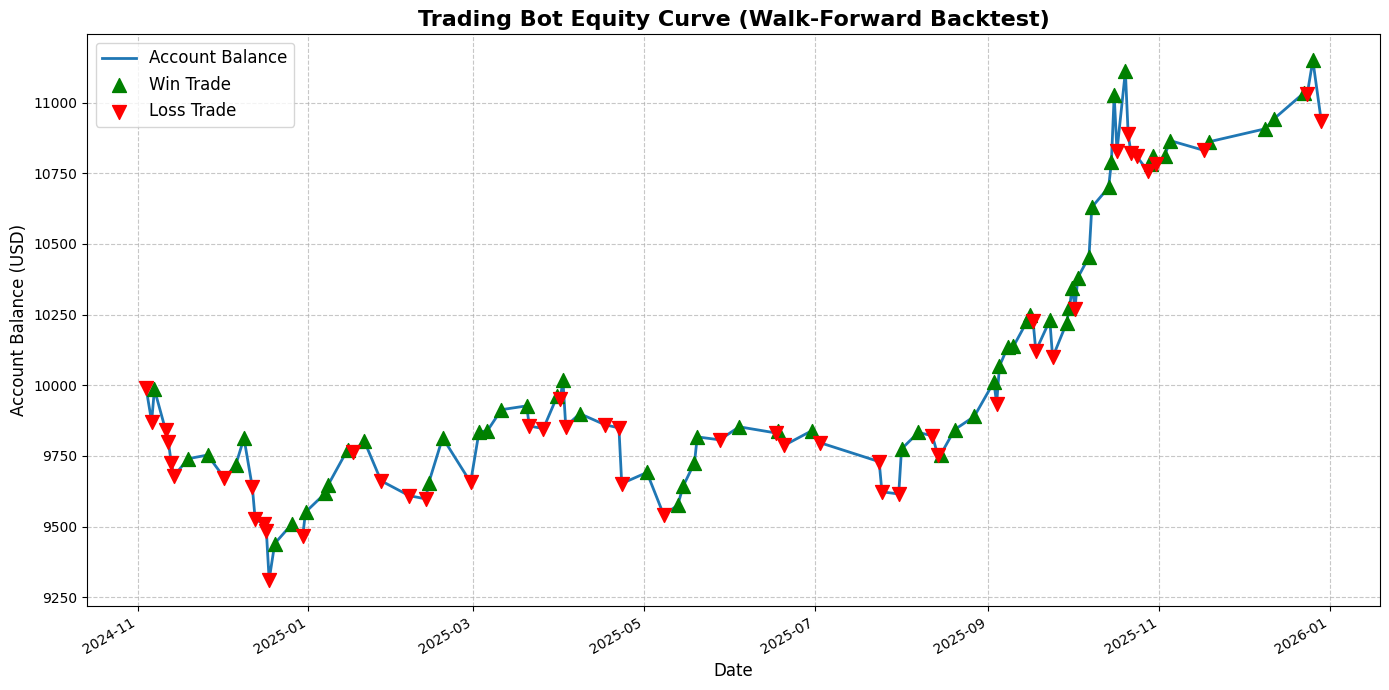

In [4]:
import matplotlib.pyplot as plt

# ตรวจสอบว่ามีข้อมูลการเทรดหรือไม่
if 'trade_results' in locals() and not trade_results.empty:
    print("กำลังสร้างกราฟ Equity Curve...")
    
    # กำหนดขนาดของกราฟ
    plt.figure(figsize=(14, 7))
    
    # ใช้ exit_date เป็นแกน X เพื่อพล็อตการเปลี่ยนแปลงของยอดเงิน
    plot_data = trade_results.set_index('exit_date')
    
    # พล็อตเส้นยอดเงินรวม (Account Balance)
    plt.plot(plot_data.index, plot_data['balance'], label='Account Balance', color='#1f77b4', linewidth=2)
    
    # แยกข้อมูลไม้ที่กำไรและขาดทุน เพื่อทำสัญลักษณ์
    win_trades = plot_data[plot_data['pnl'] > 0]
    loss_trades = plot_data[plot_data['pnl'] <= 0]
    
    # ใส่จุดสามเหลี่ยมสีเขียวสำหรับไม้ที่ชนะ
    plt.scatter(win_trades.index, win_trades['balance'], color='green', marker='^', s=100, label='Win Trade', zorder=5)
    
    # ใส่จุดสามเหลี่ยมคว่ำสีแดงสำหรับไม้ที่แพ้
    plt.scatter(loss_trades.index, loss_trades['balance'], color='red', marker='v', s=100, label='Loss Trade', zorder=5)
    
    # ตกแต่งกราฟให้สวยงาม
    plt.title('Trading Bot Equity Curve (Walk-Forward Backtest)', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Account Balance (USD)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(loc='upper left', fontsize=12)
    
    # ปรับรูปแบบวันที่แกน X ไม่ให้ทับกัน
    plt.gcf().autofmt_xdate()
    
    # แสดงกราฟ
    plt.tight_layout()
    plt.show()

else:
    print("❌ ไม่มีข้อมูลประวัติการเทรดให้พล็อตครับ (อาจจะไม่มีไม้ไหนผ่านเงื่อนไขการเทรด)")

In [5]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, classification_report

print("--- เริ่มกระบวนการ Hyperparameter Tuning ---")

# 1. ตั้งค่าการแบ่งข้อมูลทดสอบแบบ Time Series (แบ่งเป็น 5 ช่วง)
tscv = TimeSeriesSplit(n_splits=5)

# 2. กำหนดช่วงของพารามิเตอร์ที่เราต้องการให้คอมพิวเตอร์ลองสุ่มหา
# (ยิ่งใส่เยอะ ยิ่งแม่น แต่ก็ยิ่งใช้เวลาหานานขึ้นครับ)
# ปรับ Grid ใหม่: บังคับให้ต้นไม้เตี้ยลง และเพิ่มการลงโทษ (L2) หนักๆ
param_grid = {
    'learning_rate': [0.01, 0.05],          # ไม่เอาค่าสูงๆ แล้ว (ค่อยๆ เรียนชัวร์กว่า)
    'max_iter': [50, 100],                  # ลดจำนวนต้นไม้ลง (ป้องการการจำรายละเอียด)
    'max_depth': [2, 3],                    # ต้นไม้เตี้ยลง (ตัดสินใจจากเงื่อนไขแค่ 2-3 ข้อพอ)
    'l2_regularization': [1.0, 5.0, 10.0]   # *สำคัญ* เพิ่มบทลงโทษให้หนักขึ้น เพื่อลด Overfit
}

# 3. เตรียมโมเดลพื้นฐาน
base_model = HistGradientBoostingClassifier(random_state=42)

# 4. สั่งให้ค้นหาพารามิเตอร์ที่ดีที่สุด (เน้นค่า Precision)
print("กำลังค้นหาพารามิเตอร์ที่ดีที่สุด (อาจใช้เวลาสักครู่)...")
# เปลี่ยน Scoring เป็นภาพรวม (ROC AUC)
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=tscv,
    scoring='roc_auc',  # <--- เปลี่ยนตรงนี้
    n_jobs=-1,
    verbose=1
)

# 5. เริ่มเทรน (ใช้ X_train, y_train ที่มีอยู่แล้วในระบบ)
grid_search.fit(X_train, y_train)

# 6. สรุปผลลัพธ์
best_model = grid_search.best_estimator_
print("\n✅ ค้นหาสำเร็จ!")
print("พารามิเตอร์ที่ดีที่สุดคือ:", grid_search.best_params_)

# 7. ประเมินผลโมเดลตัวใหม่ (Tuned Model) บนข้อมูล Test
y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]

print("\n--- ผลลัพธ์ของโมเดลที่ปรับจูนแล้ว (Tuned Model) ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned, zero_division=0):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, zero_division=0))

--- เริ่มกระบวนการ Hyperparameter Tuning ---
กำลังค้นหาพารามิเตอร์ที่ดีที่สุด (อาจใช้เวลาสักครู่)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ ค้นหาสำเร็จ!
พารามิเตอร์ที่ดีที่สุดคือ: {'l2_regularization': 5.0, 'learning_rate': 0.05, 'max_depth': 3, 'max_iter': 100}

--- ผลลัพธ์ของโมเดลที่ปรับจูนแล้ว (Tuned Model) ---
Accuracy : 0.5017
Precision: 0.5740

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.41      0.41       122
           1       0.57      0.57      0.57       171

    accuracy                           0.50       293
   macro avg       0.49      0.49      0.49       293
weighted avg       0.50      0.50      0.50       293



In [6]:
print("\n--- รัน Backtest ด้วยโมเดลที่ปรับจูนแล้ว (Tuned Model) ---")

# นำ best_model มาใช้แทน model ตัวเดิม
trade_results_tuned = simulate_trading(
    model=best_model,      # <--- จุดสำคัญ: เราใช้ best_model แล้ว
    X_test=X_test, 
    df_original=df, 
    initial_balance=10000, 
    risk_per_trade=0.02,   # เสี่ยง 2%
    atr_multiplier=1.5,    # Stop loss 1.5 เท่าของ ATR
    prob_threshold=0.52    # ความมั่นใจขั้นต่ำ 52%
)


--- รัน Backtest ด้วยโมเดลที่ปรับจูนแล้ว (Tuned Model) ---
Starting balance: $10,000.00

--- Backtest Results ---
Total Trades : 144
Win Rate     : 56.25%
Net Profit   : $1,526.56
Final Balance: $11,526.56


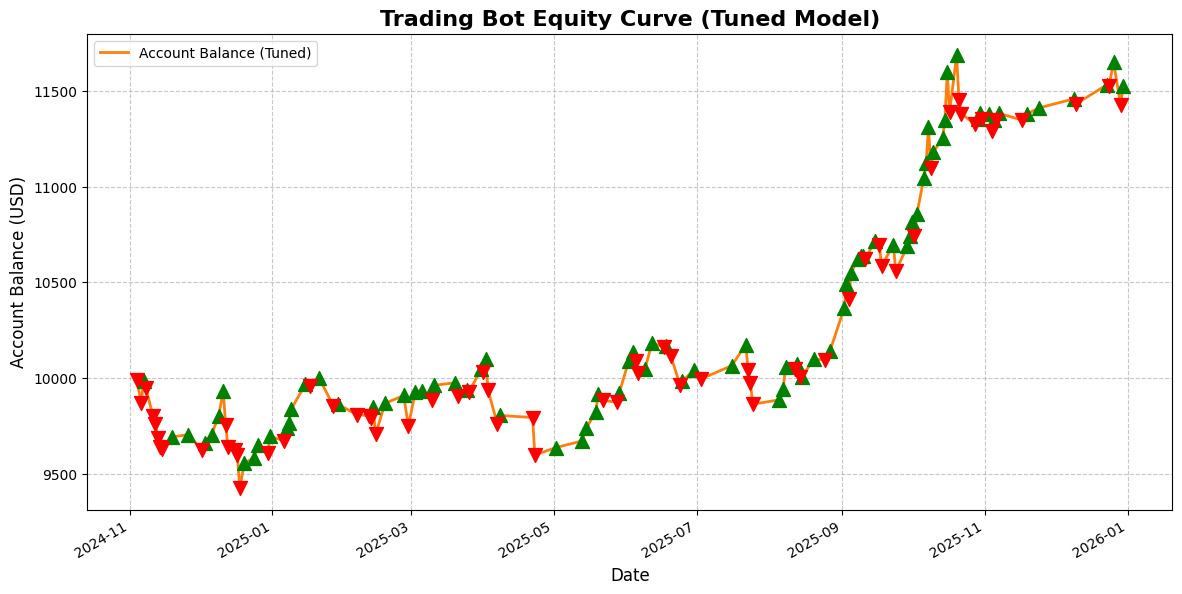

In [7]:
import matplotlib.pyplot as plt

if 'trade_results_tuned' in locals() and not trade_results_tuned.empty:
    plt.figure(figsize=(14, 7))
    plot_data = trade_results_tuned.set_index('exit_date')
    
    # พล็อตเส้นยอดเงิน
    plt.plot(plot_data.index, plot_data['balance'], label='Account Balance (Tuned)', color='#ff7f0e', linewidth=2)
    
    # จุดกำไร (เขียว) / ขาดทุน (แดง)
    win_trades = plot_data[plot_data['pnl'] > 0]
    loss_trades = plot_data[plot_data['pnl'] <= 0]
    plt.scatter(win_trades.index, win_trades['balance'], color='green', marker='^', s=100, zorder=5)
    plt.scatter(loss_trades.index, loss_trades['balance'], color='red', marker='v', s=100, zorder=5)
    
    plt.title('Trading Bot Equity Curve (Tuned Model)', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Account Balance (USD)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.gcf().autofmt_xdate()
    plt.show()
else:
    print("ไม่มีไม้เข้าเทรด ลองปรับ prob_threshold ลงเหลือ 0.52 ดูครับ")

In [8]:
import joblib
import os

# 1. เช็คและสร้างโฟลเดอร์สำหรับเก็บโมเดล (ถ้ายังไม่มี)
model_dir = os.path.join(project_root, 'models')
os.makedirs(model_dir, exist_ok=True)

# 2. บันทึกโมเดลที่ดีที่สุดลงเป็นไฟล์ .joblib
model_path = os.path.join(model_dir, 'tuned_trading_model.joblib')
joblib.dump(best_model, model_path)

print(f"✅ บันทึกโมเดลสำเร็จ! เซฟไฟล์ไว้ที่: {model_path}")

# (แถม) วิธีโหลดโมเดลกลับมาใช้ในอนาคต:
# loaded_model = joblib.load(model_path)

✅ บันทึกโมเดลสำเร็จ! เซฟไฟล์ไว้ที่: c:\Users\Gugusgus\Desktop\Tam\ml_trading_bot-main\models\tuned_trading_model.joblib
